# **Lab 03:** Transfer Learning with PyTorch and Model Improvement

## Graded Individual Activity:

In this activity, we will carry out a series of tests to evaluate the performance of our image classification model. The objective is to correctly identify whether an image contains the face of a specific student or corresponds to a background. To do this, we have defined two main labels:

##### **Label 1:** `Student Name`  
##### **Label 2:** `Background` (images that do not contain the student’s face)

#### **Tests:**

The tests will be conducted using different types of input images to verify the model’s accuracy in scenarios not seen during training:

1. **Input image:** A photo of the student that is not included in the training folder (take a photo on the day of the presentation using your webcam).  
   **Required output label:** `Student Name`

2. **Input image:** A background image that is not included in the training folder (the student presenting before you will give you a search keyword; you may download the image from Google Images).  
   **Required output label:** `Background`

3. **Input image:** A photo of a different face (not the student’s face) that is not included in the training folders (the student presenting before you will give you the name of a celebrity who resembles you; you may download the image from Google Images).  
   **Required output label:** `Background`

##### **Hyperparameter Testing:**

Additionally, you may explore the impact of various hyperparameters on the model’s performance. Examples of hyperparameters to adjust include:

- Increasing the number of images in the dataset  
- Changing the loss function  
- Changing the optimizer  
- Changing the number of training epochs  
- Changing the batch size  

These tests and adjustments will allow you to optimize the model to achieve the best possible accuracy in image classification.

##### **Results Presentation**

Students will present their results in class using a `streamlit` app. The final grade will depend on the successful completion of the 3 tests.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from PIL import Image
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [3]:
train_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [4]:
train_dataset = datasets.ImageFolder("data/train", transform=train_transforms)
val_dataset = datasets.ImageFolder("data/val", transform=val_transforms)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes

print("Classes:", class_names)
print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))

Classes: ['background', 'marck']
Training images: 655
Validation images: 166


In [5]:
model = models.resnet18(pretrained=True)

# congelar capas
for param in model.parameters():
    param.requires_grad = False

# cambiar última capa
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [6]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.0001)

In [7]:
epochs = 15

train_losses = []
val_losses = []
val_accuracies = []

best_acc = 0

for epoch in range(epochs):

    model.train()
    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)

    # VALIDATION

    model.eval()

    correct = 0
    total = 0
    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    val_loss = val_loss / len(val_loader)

    accuracy = correct / total

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{epochs}")
    print("Train Loss:", train_loss)
    print("Val Loss:", val_loss)
    print("Val Accuracy:", accuracy)
    print()

    # guardar mejor modelo

    if accuracy > best_acc:
        best_acc = accuracy
        torch.save(model.state_dict(), "best_model.pth")

Epoch 1/15
Train Loss: 0.5988529239382062
Val Loss: 0.5375494410594305
Val Accuracy: 0.7951807228915663

Epoch 2/15
Train Loss: 0.4775567026365371
Val Loss: 0.44628825783729553
Val Accuracy: 0.9096385542168675

Epoch 3/15
Train Loss: 0.3968737196354639
Val Loss: 0.36045130093892414
Val Accuracy: 0.9457831325301205

Epoch 4/15
Train Loss: 0.3289159422829038
Val Loss: 0.30562222252289456
Val Accuracy: 0.9698795180722891

Epoch 5/15
Train Loss: 0.29187787217753275
Val Loss: 0.2555859287579854
Val Accuracy: 0.9698795180722891

Epoch 6/15
Train Loss: 0.2442525795527867
Val Loss: 0.2194222758213679
Val Accuracy: 0.9759036144578314

Epoch 7/15
Train Loss: 0.22316220615591323
Val Loss: 0.1891015445192655
Val Accuracy: 0.9819277108433735

Epoch 8/15
Train Loss: 0.2081214040517807
Val Loss: 0.16700673972566923
Val Accuracy: 0.9819277108433735

Epoch 9/15
Train Loss: 0.18134409331140064
Val Loss: 0.15207651630043983
Val Accuracy: 1.0

Epoch 10/15
Train Loss: 0.15772793264616103
Val Loss: 0.134577

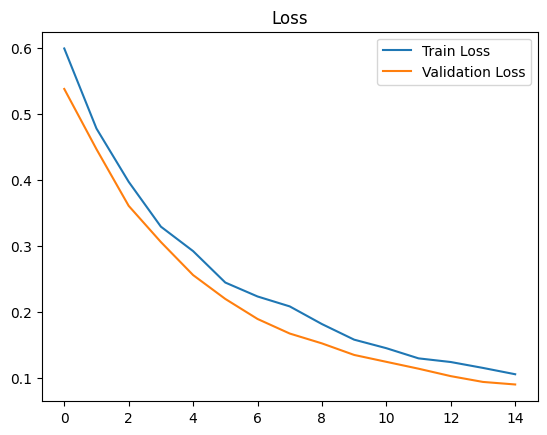

In [8]:
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Validation Loss")
plt.legend()
plt.title("Loss")
plt.show()

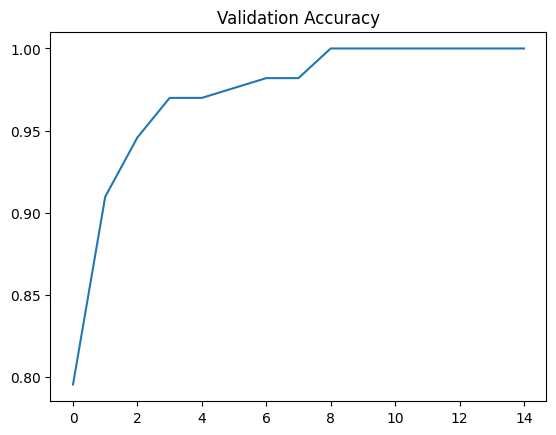

In [9]:
plt.plot(val_accuracies)
plt.title("Validation Accuracy")
plt.show()

In [10]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [11]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    image = val_transforms(image).unsqueeze(0).to(device)

    with torch.no_grad():

        outputs = model(image)

        probabilities = torch.softmax(outputs, dim=1)

        confidence, predicted = torch.max(probabilities,1)

    return class_names[predicted.item()], confidence.item()*100

In [12]:
predict_image("test.jpg")

('background', 66.09302163124084)

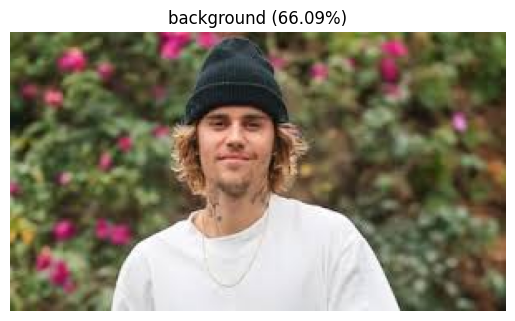

In [13]:
img = "test.jpg"

prediction, confidence = predict_image(img)

image = Image.open(img)

plt.imshow(image)
plt.axis("off")

plt.title(f"{prediction} ({confidence:.2f}%)")

plt.show()

### **Grading Rubric (10 points)**

The Streamlit app should be working correctly during presentation to get points.

| Criterion | Points |
|----------|--------|
| Test 1: Correct classification of student's new photo (`Student Name`) | 2.5 |
| Test 2: Correct classification of unseen background image (`Background`) | 2.5 |
| Test 3: Correct classification of a different face (celebrity look-alike) as `Background` | 5 |
| **Total** | **10** |

### **Scoring Rules**

- Each test is graded as **pass (full points)** or **fail (0 points)**.
- If the model predicts the required label correctly → full points for that test.
- If the prediction is incorrect → 0 points for that test.
- Test 3 has the highest weight because it evaluates the model’s ability to generalize and avoid false positives.

---

<p style="text-align: right; font-size:14px; color:gray;">
<b>Prepared by:</b><br>
Manuel Eugenio Morocho-Cayamcela
</p>